# BulkFluoRDF Subpopulation Analysis

This notebook looks for SPEN hub subpopulations based on local H3K27ac RDF near each hub. It uses the existing final pipeline outputs in `results/` and does not rerun Cellpose or Spotiflow.

Definitions used here:
- `RDF(r<200 nm)` = average `h3k27ac_rdf_local_norm` across the first three RDF bins.
- high-H3K27ac SPEN hubs = top quantile of `RDF(r<200 nm)`.
- low-H3K27ac SPEN hubs = bottom quantile of `RDF(r<200 nm)`.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from matplotlib.colors import ListedColormap
import seaborn as sns
import tifffile
from skimage import segmentation

import BulkFluoRDF as rdf

RESULTS_DIR = Path('results')
OUT_DIR = RESULTS_DIR / 'subpopulation_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='white', context='notebook')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


## Parameters

Adjust these values in the notebook rather than editing `config.yaml`.


In [ ]:
params = {
    # First three bins are 0-100, 50-150, and 100-200 nm in the current pipeline.
    'near_bin_count': 3,
    'quantile': 0.1,
    'rdf_column': 'h3k27ac_rdf_local_norm',
    'spen_rdf_column': 'spen_rdf_local_norm',
    'intensity_metric': 'spotiflow_intensity',
    # Preferred size columns if future pipeline outputs add true punctum size.
    'size_metric_candidates': [
        'spen_punctum_area_px',
        'punctum_area_px',
        'area_px',
        'equivalent_diameter_nm',
        'equivalent_diameter_px',
        'spen_local_area_px',
    ],
    'palette': {
        'low-H3K27ac SPEN hubs': '#00274c',
        'high-H3K27ac SPEN hubs': '#9a3324',
    },
    'overlay_dir': OUT_DIR / 'overlays',
    'overlay_crop_padding_px': 25,
    'overlay_hub_circle_size': 36,
    'overlay_scale_bar_um': 1.0,
    'pixel_size_nm': 58.5,
}
params


## Load Pipeline Outputs

In [36]:
hub_props = pd.read_csv(RESULTS_DIR / 'hub_properties.csv')
hub_rdf = pd.read_csv(RESULTS_DIR / 'hub_rdf_results.csv')

kept_hubs = hub_props[hub_props['keep_hub'].astype(bool)].copy()
hub_rdf = hub_rdf[hub_rdf['hub_uid'].isin(kept_hubs['hub_uid'])].copy()

print(f'Retained hubs: {kept_hubs.hub_uid.nunique()}')
print(f'Hub RDF rows: {len(hub_rdf)}')
print(f'RDF bins: {hub_rdf.bin_index.nunique()}')
hub_rdf.head()


Retained hubs: 3115
Hub RDF rows: 59185
RDF bins: 19


,fov,hub_id,hub_uid,nucleus_id,radius_start_nm,radius_end_nm,radius_center_nm,bin_index,h3k27ac_sum_intensity,h3k27ac_mean_intensity,...,spen_median_intensity,expected_spen_sum_intensity,local_spen_mean,local_reference_pixel_count,h3k27ac_rdf_local_norm,spen_rdf_local_norm,pixel_count,spotiflow_intensity,nucleus_spen_median,nucleus_h3k27ac_mean
0,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,2,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,1,0.0,100.0,50.0,0,0.391067,0.043452,...,0.682806,4.275648,0.475072,915,0.969943,1.425410,9,0.6894,0.405529,0.069359
1,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,2,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,1,50.0,150.0,100.0,1,0.839842,0.044202,...,0.651207,9.026367,0.475072,915,0.986691,1.378398,19,0.6894,0.405529,0.069359
2,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,2,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,1,100.0,200.0,150.0,2,1.262457,0.045088,...,0.614964,13.302015,0.475072,915,1.006459,1.300213,28,0.6894,0.405529,0.069359
3,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,2,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,1,150.0,250.0,200.0,3,1.653256,0.045924,...,0.580785,17.102591,0.475072,915,1.025121,1.209009,36,0.6894,0.405529,0.069359
4,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,2,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,1,200.0,300.0,250.0,4,2.160664,0.046971,...,0.529214,21.853310,0.475072,915,1.048496,1.129574,46,0.6894,0.405529,0.069359


## Per-Hub RDF(r<200 nm)

The current RDF bins are overlapping physical bins. The first three bins correspond to `0-100`, `50-150`, and `100-200 nm`, so their average is labeled `RDF(r<200 nm)` for screening.


In [37]:
first_bins = sorted(hub_rdf['bin_index'].dropna().unique())[:params['near_bin_count']]
near = hub_rdf[hub_rdf['bin_index'].isin(first_bins)].copy()
bin_table = near[['bin_index', 'radius_start_nm', 'radius_end_nm']].drop_duplicates().sort_values('bin_index')
display(bin_table)

near_metric = (
    near.groupby('hub_uid', as_index=False)
    .agg(
        rdf_r_lt_200nm=(params['rdf_column'], 'mean'),
        spen_rdf_r_lt_200nm=(params['spen_rdf_column'], 'mean'),
        fov=('fov', 'first'),
        nucleus_id=('nucleus_id', 'first'),
        spotiflow_intensity=('spotiflow_intensity', 'first'),
    )
)

hub_table = kept_hubs.merge(
    near_metric[['hub_uid', 'rdf_r_lt_200nm', 'spen_rdf_r_lt_200nm']],
    on='hub_uid',
    how='inner',
)

hub_table.to_csv(OUT_DIR / 'hub_rdf_r_lt_200nm.csv', index=False)
hub_table[['hub_uid', 'fov', 'nucleus_id', 'spotiflow_intensity', 'rdf_r_lt_200nm']].head()


,bin_index,radius_start_nm,radius_end_nm
0,0,0.0,100.0
1,1,50.0,150.0
2,2,100.0,200.0


,hub_uid,fov,nucleus_id,spotiflow_intensity,rdf_r_lt_200nm
0,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,1,0.6894,0.987698
1,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,1,0.6351,0.963848
2,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,1,0.7037,1.000995
3,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,1,0.7121,1.066553
4,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV...,TXSHA-undiff-SPEN_JF549_H3K27ac_DL650-SACD-FOV,1,0.6923,0.964275


## Histogram Of H3K27ac RDF(r<200 nm)

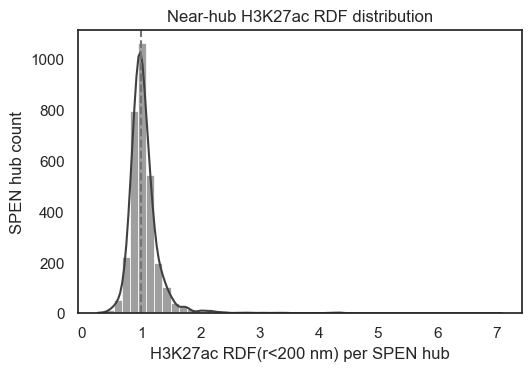

In [38]:
fig, ax = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)
sns.histplot(
    data=hub_table,
    x='rdf_r_lt_200nm',
    bins=50,
    kde=True,
    color='0.25',
    ax=ax,
)
ax.axvline(1.0, color='0.45', ls='--', lw=1.5)
ax.set_xlabel('H3K27ac RDF(r<200 nm) per SPEN hub')
ax.set_ylabel('SPEN hub count')
ax.set_title('Near-hub H3K27ac RDF distribution')
fig.savefig(OUT_DIR / 'hist_h3k27ac_rdf_r_lt_200nm.png', dpi=300, bbox_inches='tight')
plt.show()


## Top/Bottom Quantile Selection

In [39]:
q = float(params['quantile'])
low_cut = hub_table['rdf_r_lt_200nm'].quantile(q)
high_cut = hub_table['rdf_r_lt_200nm'].quantile(1 - q)

hub_table['rdf_subpopulation'] = 'middle'
hub_table.loc[hub_table['rdf_r_lt_200nm'] <= low_cut, 'rdf_subpopulation'] = 'low-H3K27ac SPEN hubs'
hub_table.loc[hub_table['rdf_r_lt_200nm'] >= high_cut, 'rdf_subpopulation'] = 'high-H3K27ac SPEN hubs'

selected = hub_table[hub_table['rdf_subpopulation'].isin(params['palette'])].copy()
selected.to_csv(OUT_DIR / 'h3k27ac_rdf_quantile_hubs.csv', index=False)

print(f'Quantile: {q:g}')
print(f'Low cutoff:  {low_cut:.4f}')
print(f'High cutoff: {high_cut:.4f}')
display(selected['rdf_subpopulation'].value_counts().rename_axis('subpopulation').reset_index(name='n_hubs'))


Quantile: 0.1
Low cutoff:  0.8245
High cutoff: 1.2995


,subpopulation,n_hubs
0,low-H3K27ac SPEN hubs,312
1,high-H3K27ac SPEN hubs,312


## Subpopulation Hub Overlays

Write one side-by-side SPEN/H3K27ac crop per picked nucleus, showing only the high- and low-H3K27ac SPEN hubs selected above.


In [ ]:
def add_scale_bar(ax, crop_shape, pixel_size_nm, scale_bar_um=1.0):
    bar_px = float(scale_bar_um) * 1000.0 / float(pixel_size_nm)
    margin = max(8, int(min(crop_shape) * 0.05))
    x1 = crop_shape[1] - margin
    x0 = x1 - bar_px
    y = crop_shape[0] - margin
    ax.plot([x0, x1], [y, y], color='white', lw=3, solid_capstyle='butt')
    ax.text(
        (x0 + x1) / 2,
        y - max(4, margin * 0.35),
        f'{scale_bar_um:g} um',
        color='white',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold',
        path_effects=[pe.withStroke(linewidth=2, foreground='black')],
    )


def make_subpopulation_overlay(
    fov,
    nucleus_id,
    nucleus_hubs,
    object_image,
    intensity_image,
    nuclei,
    out_dir,
    palette,
    pixel_size_nm,
    padding_px=25,
    circle_size=36,
    scale_bar_um=1.0,
):
    mask = nuclei == int(nucleus_id)
    yy, xx = np.where(mask)
    if yy.size == 0:
        raise ValueError(f'No pixels found for {fov} nucleus {nucleus_id}')

    y0 = max(0, int(yy.min()) - int(padding_px))
    y1 = min(nuclei.shape[0], int(yy.max()) + int(padding_px) + 1)
    x0 = max(0, int(xx.min()) - int(padding_px))
    x1 = min(nuclei.shape[1], int(xx.max()) + int(padding_px) + 1)

    object_display = rdf.normalize01(object_image)
    intensity_display = rdf.normalize01(intensity_image)
    boundary_crop = segmentation.find_boundaries(mask, mode='outer')[y0:y1, x0:x1]
    crop_shape = boundary_crop.shape

    counts = nucleus_hubs['rdf_subpopulation'].value_counts()
    high_label = 'high-H3K27ac SPEN hubs'
    low_label = 'low-H3K27ac SPEN hubs'
    high_n = int(counts.get(high_label, 0))
    low_n = int(counts.get(low_label, 0))

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 4.2), constrained_layout=True)
    for ax, display, channel, cmap in (
        (axes[0], object_display, 'SPEN', 'magma'),
        (axes[1], intensity_display, 'H3K27ac', 'gray'),
    ):
        ax.imshow(display[y0:y1, x0:x1], cmap=cmap)
        ax.imshow(
            np.ma.masked_where(~boundary_crop, boundary_crop),
            cmap=ListedColormap(['white']),
            alpha=0.9,
        )
        for label in (low_label, high_label):
            hubs = nucleus_hubs[nucleus_hubs['rdf_subpopulation'] == label]
            if hubs.empty:
                continue
            ax.scatter(
                hubs['hub_x'].astype(float) - x0,
                hubs['hub_y'].astype(float) - y0,
                s=float(circle_size),
                facecolors='none',
                edgecolors=palette[label],
                linewidths=1.2,
            )
        add_scale_bar(ax, crop_shape, pixel_size_nm, scale_bar_um)
        ax.set_title(channel, fontsize=10)
        ax.set_axis_off()

    fig.suptitle(f'{fov} nucleus {int(nucleus_id):03d}: high={high_n}, low={low_n}', fontsize=10)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{fov}_nucleus_{int(nucleus_id):03d}_subpopulation_overlay.png'
    fig.savefig(out_path, dpi=250, bbox_inches='tight')
    plt.close(fig)
    return out_path


selected_for_overlay = pd.read_csv(OUT_DIR / 'h3k27ac_rdf_quantile_hubs.csv')
selected_for_overlay = selected_for_overlay[selected_for_overlay['rdf_subpopulation'].isin(params['palette'])].copy()
paired_inputs = pd.read_csv(RESULTS_DIR / 'paired_inputs.csv').set_index('fov')
overlay_dir = Path(params['overlay_dir'])

overlay_paths = []
for fov, fov_hubs in selected_for_overlay.groupby('fov', sort=True):
    if fov not in paired_inputs.index:
        raise ValueError(f'Missing paired_inputs row for {fov}')
    pair = paired_inputs.loc[fov]
    object_image = rdf.read_image(pair['object_path'])
    intensity_image = rdf.read_image(pair['intensity_path'])
    mask_path = RESULTS_DIR / 'nucleus_masks' / f'{fov}_nuclei.tif'
    nuclei = tifffile.imread(mask_path)

    for nucleus_id, nucleus_hubs in fov_hubs.groupby('nucleus_id', sort=True):
        overlay_paths.append(
            make_subpopulation_overlay(
                fov=fov,
                nucleus_id=nucleus_id,
                nucleus_hubs=nucleus_hubs,
                object_image=object_image,
                intensity_image=intensity_image,
                nuclei=nuclei,
                out_dir=overlay_dir,
                palette=params['palette'],
                pixel_size_nm=params['pixel_size_nm'],
                padding_px=params['overlay_crop_padding_px'],
                circle_size=params['overlay_hub_circle_size'],
                scale_bar_um=params['overlay_scale_bar_um'],
            )
        )

picked_nuclei = selected_for_overlay[['fov', 'nucleus_id']].drop_duplicates().shape[0]
print(f'Selected subpopulation hubs: {selected_for_overlay.hub_uid.nunique()}')
print(f'Picked nucleus/FOV pairs: {picked_nuclei}')
print(f'Overlay PNGs written: {len(overlay_paths)}')
display(pd.DataFrame({'overlay_path': [str(p) for p in overlay_paths]}).head())


## Aggregated RDF For High/Low H3K27ac SPEN Hubs

These plots use the same convention as the main package: individual hub curves in the background and group mean ± STD as error bars. X values are the left bound of each RDF bin.


In [40]:
def summarize_group_rdf(rdf_df, group_hubs, value_col):
    dat = rdf_df[rdf_df['hub_uid'].isin(group_hubs)].copy()
    rows = []
    for (bin_index, r0, r1), g in dat.groupby(['bin_index', 'radius_start_nm', 'radius_end_nm'], sort=True):
        vals = g[value_col].replace([np.inf, -np.inf], np.nan).dropna().astype(float)
        rows.append({
            'bin_index': int(bin_index),
            'radius_start_nm': float(r0),
            'radius_end_nm': float(r1),
            'mean': float(vals.mean()) if len(vals) else np.nan,
            'std': float(vals.std(ddof=1)) if len(vals) > 1 else np.nan,
            'n_hubs': int(vals.size),
        })
    return pd.DataFrame(rows)

summary_rows = []
for label, hubs in selected.groupby('rdf_subpopulation')['hub_uid']:
    h3 = summarize_group_rdf(hub_rdf, hubs, params['rdf_column'])
    h3['rdf_subpopulation'] = label
    h3['channel'] = 'H3K27ac'
    sp = summarize_group_rdf(hub_rdf, hubs, params['spen_rdf_column'])
    sp['rdf_subpopulation'] = label
    sp['channel'] = 'SPEN'
    summary_rows.extend([h3, sp])
subpop_rdf_summary = pd.concat(summary_rows, ignore_index=True)
subpop_rdf_summary.to_csv(OUT_DIR / 'subpopulation_aggregated_rdf.csv', index=False)
subpop_rdf_summary.head()


,bin_index,radius_start_nm,radius_end_nm,mean,std,n_hubs,rdf_subpopulation,channel
0,0,0.0,100.0,1.746756,0.740664,312,high-H3K27ac SPEN hubs,H3K27ac
1,1,50.0,150.0,1.666441,0.621432,312,high-H3K27ac SPEN hubs,H3K27ac
2,2,100.0,200.0,1.551455,0.509524,312,high-H3K27ac SPEN hubs,H3K27ac
3,3,150.0,250.0,1.425886,0.431445,312,high-H3K27ac SPEN hubs,H3K27ac
4,4,200.0,300.0,1.303119,0.361190,312,high-H3K27ac SPEN hubs,H3K27ac


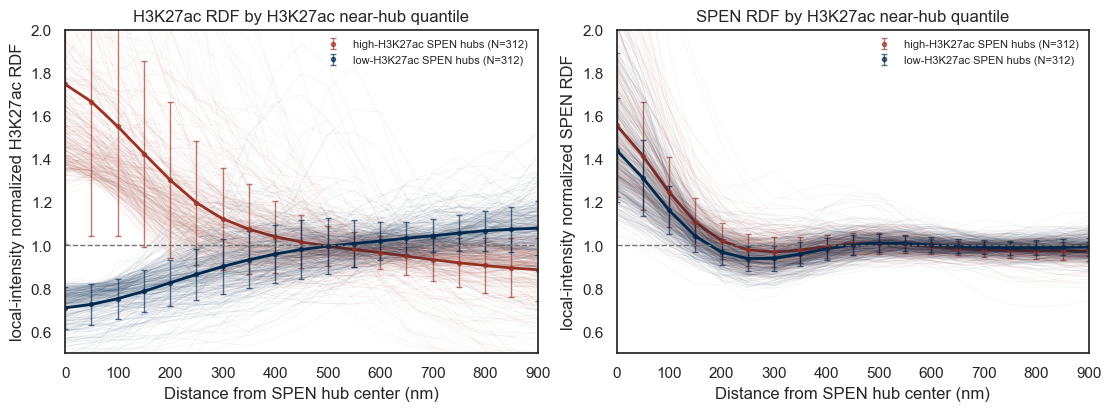

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True, sharex=True)
plot_specs = [
    (axes[0], params['rdf_column'], 'H3K27ac', 'local-intensity normalized H3K27ac RDF'),
    (axes[1], params['spen_rdf_column'], 'SPEN', 'local-intensity normalized SPEN RDF'),
]
for ax, value_col, channel, ylabel in plot_specs:
    for label, group in selected.groupby('rdf_subpopulation'):
        color = params['palette'][label]
        hubs = group['hub_uid'].tolist()
        draw = hub_rdf[hub_rdf['hub_uid'].isin(hubs)].copy()
        for _, curve in draw.groupby('hub_uid'):
            ax.plot(curve['radius_start_nm'], curve[value_col], color=color, alpha=0.06, lw=0.55)
        summ = subpop_rdf_summary[(subpop_rdf_summary['rdf_subpopulation'] == label) & (subpop_rdf_summary['channel'] == channel)]
        ax.errorbar(
            summ['radius_start_nm'],
            summ['mean'],
            yerr=summ['std'],
            fmt='.',
            color=color,
            ecolor=color,
            elinewidth=1,
            capsize=2,
            alpha=0.65,
            label=f'{label} (N={int(summ.n_hubs.max())})',
        )
        ax.plot(summ['radius_start_nm'], summ['mean'], color=color, lw=2)
    ax.axhline(1, color='0.45', ls='--', lw=1)
    ax.set_xlim(hub_rdf['radius_start_nm'].min(), hub_rdf['radius_start_nm'].max())
    y0, y1 = ax.get_ylim()
    if y0 < 0.5 or y1 > 2:
        ax.set_ylim(0.5, 2)
    ax.set_xlabel('Distance from SPEN hub center (nm)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{channel} RDF by H3K27ac near-hub quantile')
    ax.legend(frameon=False, fontsize=8)
fig.savefig(OUT_DIR / 'subpopulation_aggregated_rdf.png', dpi=300, bbox_inches='tight')
plt.show()


## SPEN Hub Intensity Versus Size

The main pipeline currently stores Spotiflow intensity. It does not yet store a true connected-component punctum size in `hub_properties.csv`. This cell uses the first available size-like column from `params['size_metric_candidates']`. If only `spen_local_area_px` is available, interpret it as a local support-size proxy rather than a true punctum area.


In [42]:
size_metric = next((c for c in params['size_metric_candidates'] if c in selected.columns), None)
if size_metric is None:
    raise ValueError('No size-like metric found. Add a punctum size column to hub_properties.csv or update size_metric_candidates.')

size_labels = {
    'spen_punctum_area_px': 'SPEN hub area (px)',
    'punctum_area_px': 'SPEN hub area (px)',
    'area_px': 'SPEN hub area (px)',
    'equivalent_diameter_nm': 'SPEN hub equivalent diameter (nm)',
    'equivalent_diameter_px': 'SPEN hub equivalent diameter (px)',
    'spen_local_area_px': 'SPEN hub size proxy: local r100nm support area (px)',
}
print(f'Using size metric: {size_metric}')


Using size metric: spen_local_area_px


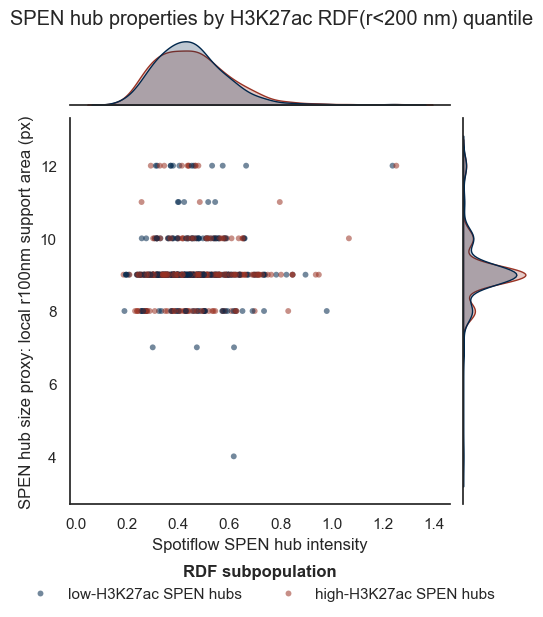

In [48]:
plot_df = selected.copy()
plot_df = plot_df[np.isfinite(plot_df[params['intensity_metric']]) & np.isfinite(plot_df[size_metric])]

g = sns.jointplot(
    data=plot_df,
    x=params['intensity_metric'],
    y=size_metric,
    hue='rdf_subpopulation',
    palette=params['palette'],
    kind='scatter',
    marginal_kws={'common_norm': False, 'fill': True, 'alpha': 0.25},
    joint_kws={'alpha': 0.55, 's': 18, 'linewidth': 0},
    height=5.5,
)
legend = g.ax_joint.get_legend()
legend.set_frame_on(False)
legend.set_title('RDF sub-population')
legend.get_title().set_fontweight('bold')
sns.move_legend(
    g.ax_joint,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    title='RDF subpopulation',
    ncol=2,  # spread entries horizontally
)
g.set_axis_labels('Spotiflow SPEN hub intensity', size_labels.get(size_metric, size_metric))
g.fig.suptitle('SPEN hub properties by H3K27ac RDF(r<200 nm) quantile', y=1.02)
g.fig.savefig(OUT_DIR / 'subpopulation_spen_intensity_vs_size_jointplot.png', dpi=300, bbox_inches='tight')
plt.show()


## Output Files

Generated files are written to `results/subpopulation_analysis/`:
- `hub_rdf_r_lt_200nm.csv`
- `h3k27ac_rdf_quantile_hubs.csv`
- `subpopulation_aggregated_rdf.csv`
- `hist_h3k27ac_rdf_r_lt_200nm.png`
- `subpopulation_aggregated_rdf.png`
- `subpopulation_spen_intensity_vs_size_jointplot.png`
- `overlays/*.png`
